In [144]:
import numpy as np
import matplotlib.pyplot as plt

# Undulators with calibrated coefficients

In [145]:
class MGU:
    def get_mgu_beff(self, source, gap):
        """Calculate peak magnetic field for a given gap (Halbach equation).

        MGU is an Moveble Gap Undulator.

        Args:
            gap_over_period (float): gap normalized by the undulator period.
            br (float): Remanent field in [T]
            a (float): Halbach coefficient 'a'.
            b (float): Halbach coefficient 'b'.
            c (float): Halbach coefficient 'c'.

        Returns:
            float: Effective field B_eff
        """
        gap_over_period, br, a, b, c = (
            gap / source.period,
            source.br,
            source.halbach_coef[source.polarization]["a"],
            source.halbach_coef[source.polarization]["b"],
            source.halbach_coef[source.polarization]["c"],
        )
        return a * br * np.exp(b * gap_over_period + c * (gap_over_period**2))


class APU(MGU):
    def get_apu_beff(self, source, phase=None):
        """Get peak magnetic field for a given device and gap.

        APU is an Adjustable Phase Undulator.

        Args:
            gap_over_period (float): gap normalized by the undulator period.

        Returns:
            _type_: _description_
        """
        phase = source.phase if phase is None else phase
        z0 = source.phase_coef[source.polarization]["z0"]
        efficiency = source.phase_coef[source.polarization]["ef"]
        return (
            efficiency
            * self.get_mgu_beff(source=source, gap=source.min_gap)
            * np.abs(np.cos(np.pi / source.period * (phase - z0)))
        )


#  APUs
class APU22_1991B_MNC(APU):
    """APU MNC.

    Coefficients obtained from the fit of the measurement data of the
    MNC undulator. Data available at the ima organization github in the
    repo: https://github.com/lnls-ima/id-manaca.git
    """

    def __init__(self):
        self.period = 22.0
        self.min_gap = 8.0
        self.phase = 0.0
        self.br = 1.34
        self.polarization = "hp"
        self.halbach_coef = {"hp": {"a": 1.732, "b": -3.238, "c": 0.0}}
        self.phase_coef = {"hp": {"ef": 1.0022029, "z0": -0.300609}}


class APU22_1991D_SPU(APU):
    """APU SPU.

    Coefficients obtained from the fit of the measurement data of the
    SAPUCAIA undulator. Data available at the ima organization github in the
    repo: https://github.com/lnls-ima/id-ema.git

    This undulator used to be from EMA beamline, but it is now from SAPUCAIA.
    """

    def __init__(self):
        self.period = 22.0
        self.min_gap = 8.0
        self.phase = 0.0
        self.br = 1.34
        self.polarization = "hp"
        self.halbach_coef = {"hp": {"a": 1.732, "b": -3.238, "c": 0.0}}
        self.phase_coef = {"hp": {"ef": 0.9981, "z0": 0.321}}


# TODO: APU ARIRANHA
class APU22_1991C_ARI(APU):
    """APU ARI.

    Coefficients obtained from the fit of the measurement data of the
    ARIRANHA undulator. Data available at the ima organization github in the
    repo: https://github.com/lnls-ima/id-carnauba.git

    This undulator used to be from CARNAUBA beamline, but it is now from
    ARIRANHA.
    """

    def __init__(self):
        self.period = 22.0
        self.min_gap = 8.0
        self.phase = 0.0
        self.br = 1.34
        self.polarization = "hp"
        self.halbach_coef = {"hp": {"a": 1.732, "b": -3.238, "c": 0.0}}
        self.phase_coef = {"hp": {"ef": 0.95723745, "z0": -0.18569034}}


#  DELTA
class DELTA52_SAB(APU):
    """DELTA SAB.

    Coefficients obtained from the fit of the measurement data of the
    SABIA undulator. Data available at the ima organization github in the
    repo: https://github.com/lnls-ima/id-sabia.git
    """

    def __init__(self):
        self.period = 52.5
        self.min_gap = 13.6
        self.phase = 26.25
        self.br = 1.39
        self.polarization = "hp"
        self.halbach_coef = {
            "hp": {"a": 1.696, "b": -2.349, "c": -0.658},
            "vp": {"a": 1.696, "b": -2.349, "c": -0.658},
            "cp": {"a": 1.696, "b": -2.349, "c": -0.658},
        }
        self.phase_coef = {
            "hp": {"ef": 1.00566, "z0": 25.89527},
            "vp": {"ef": 0.99032, "z0": 26.08821},
            "cp": {"ef": 0.71497, "z0": 25.89593},
        }


#  IVUs
class IVU18_1_PNR(MGU):
    """IVU PNR.

    Coefficients obtained from the fit of the measurement data of the
    PAINEIRA undulator. Data available at the sharepoint Undulators in the
    folder: https://cnpemcamp.sharepoint.com/:f:/s/lnls/projects/Undulators/IgBpAvt3uf_1S7GbpbJE43ZEAQcuq71O0H_gg_74WeOCOC8?e=kFCQ4v
    """

    def __init__(self):
        self.period = 18.5
        self.min_gap = 4.3
        self.br = 1.27
        self.polarization = "hp"
        self.halbach_coef = {
            "hp": {"a": 2.29044642, "b": -3.71638253, "c": 0.34898287},
        }


class IVU18_2_EMA(MGU):
    """IVU EMA.

    Coefficients obtained from the fit of the measurement data of the
    EMA undulator. Data available at the sharepoint Undulators in the
    folder: https://cnpemcamp.sharepoint.com/:f:/s/lnls/projects/Undulators/IgARGR7V1PbUT7t4Gw8GvpxMAY8hM8mLX1V2sWo-HbsUD7g?e=J239kC
    """

    def __init__(self):
        self.period = 18.5
        self.min_gap = 4.3
        self.br = 1.27
        self.polarization = "hp"
        self.halbach_coef = {
            "hp": {"a": 2.26223181, "b": -3.69776472, "c": 0.32867209},
        }


# VPUs
class VPU29_B_CNB(MGU):
    """VPU CNB.

    Coefficients obtained from the fit of the measurement data of the
    CARNAUBA undulator. Data available at the ima organization github in the
    repo: https://github.com/lnls-ima/id-VPU29-2386b
    """

    def __init__(self):
        self.period = 29.0
        self.min_gap = 9.7
        self.br = 1.304
        self.polarization = "vp"
        self.halbach_coef = {
            "vp": {"a": 2.03304573, "b": -3.4431994, "c": 0.18171406},
        }


class VPU29_A_CAT(MGU):
    """VPU CAT.

    Coefficients obtained from the fit of the measurement data of the
    CARNAUBA undulator.  Data available at the sharepoint Undulators in the
    folder: https://cnpemcamp.sharepoint.com/:f:/s/lnls/projects/Undulators/IgARGR7V1PbUT7t4Gw8GvpxMAY8hM8mLX1V2sWo-HbsUD7g?e=J239kC
    """

    def __init__(self):
        self.period = 29.0
        self.min_gap = 9.7
        self.br = 1.30
        self.polarization = "vp"
        self.halbach_coef = {
            "vp": {"a": 1.9586, "b": -3.4126, "c": 0.1496},
        }


# UE
class UE44_IPE(APU):
    """VPU CAT.

    Coefficients obtained from the fit of the measurement data of the
    CARNAUBA undulator.  Data available at the sharepoint Undulators in the
    folder: https://cnpemcamp.sharepoint.com/:f:/s/lnls/projects/Undulators/IgA3bd53KAlKSJ_5A4QNXcnWASNjCeDJ-RjK-mj16EaL4tw?e=s6iVw6
    """

    def __init__(self):
        self.period = 44.0
        self.min_gap = 11.4
        self.phase = 0.0
        self.br = 1.14
        self.polarization = "hp"
        self.halbach_coef = {
            "hp": {"a": 1.4934, "b": -2.5933, "c": -0.4855},
            "vp": {"a": 2.0362, "b": -5.4204, "c": 1.1888},
            "cp": {"a": 1.6558, "b": -5.1381, "c": 1.4244},
            "lp54x": {"a": 1.3581, "b": -4.5943, "c": 0.8108},
        }
        self.phase_coef = {
            "hp": {"ef": 1.0205, "z0": -0.028},
            "vp": {"ef": 0.9933, "z0": -0.062},
            "cp": {"ef": 0.9116, "z0": 0.0245},
            "lp54x": {"ef": 1.0041, "z0": -0.047},
        }

# Tables Generate

## APUs (Horizontal polarization)

### APU22 (1991b) MANACÁ 09SA 

In [146]:
apu22_mnc_1991b = APU22_1991B_MNC()

(
    apu22_mnc_1991b.polarization,
    apu22_mnc_1991b.phase,
    apu22_mnc_1991b.get_apu_beff(apu22_mnc_1991b, phase=0),
    apu22_mnc_1991b.min_gap,
)

('hp', 0.0, 0.7158896205521033, 8.0)

In [147]:
apu22_mnc_1991b.halbach_coef, apu22_mnc_1991b.phase_coef, apu22_mnc_1991b.br

({'hp': {'a': 1.732, 'b': -3.238, 'c': 0.0}},
 {'hp': {'ef': 1.0022029, 'z0': -0.300609}},
 1.34)

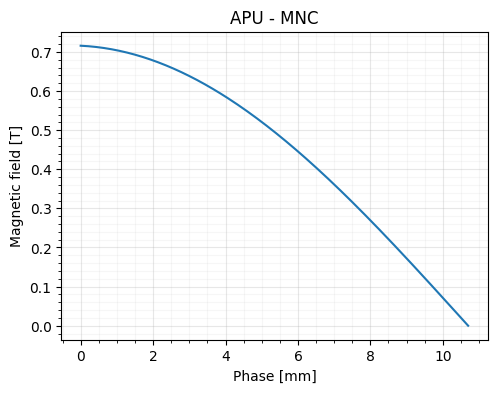

In [148]:
phases = np.linspace(0, apu22_mnc_1991b.period/2 + apu22_mnc_1991b.phase_coef["hp"]["z0"], 201)
apu22_mnc_1991b.phase = phases

fields_eff_y = apu22_mnc_1991b.get_apu_beff(apu22_mnc_1991b, phase=phases)

plt.figure(figsize=(5.5, 4))
plt.title('APU - MNC')
plt.plot(phases, fields_eff_y)
plt.xlabel('Phase [mm]')
plt.ylabel('Magnetic field [T]')
plt.grid(which='major', alpha=0.3)
plt.grid(which='minor', alpha=0.1)
plt.minorticks_on()
plt.show()

In [149]:
data_apu_mnc = np.zeros((fields_eff_y.size, 3))
data_apu_mnc[:, 0] = phases
data_apu_mnc[:, 1] = fields_eff_y * apu22_mnc_1991b.period * 1e-3

In [150]:
header = """# HEADER
# ======
# label             si-id-apu22-1991b-horizontal
# harmonics         0
# main_harmonic     0 normal
# rescaling_factor  1.0
# units             mm   T.m T.m


# KParam    By[T]*Lamba[m]    Bx[T]*Lambda[m]
# =========================================="""


footer = """
# COMMENTS
# ========
#
# 1. Measurement data at the lnls-ima organization github in the repo:
#    https://github.com/lnls-ima/id-manaca.git
#
# 2. K ~ 93.3729/(T.m) * (lambda * B)
#    This table contains lambda * B as a function of the ID configuration.
#    In terms of maximum deflection angle,
#        lambda * B == 2 * pi * Brho * x'_max
#        where x'_max is taken from fitting RK trajectory within
#        40 central periods (20 before and 20 after the ID center)
#
# 3. Polynomial of order 6 is fitted to data in order to filter out
#    data fluctuations. In this case the number of data points was not
#    increased in the fitting process.
#
# 4. Excdata is generated with script
#    'generate_tables.ipynb' at the lnls-ids organization github in the
#    excitation_data folder of the repo:
#    https://github.com/lnls-ids/insertion-devices.git'"""


np.savetxt(
    "./excitation_tables/si-id-apu22-1991b-horizontal.txt",
    data_apu_mnc,
    fmt=["%05.2f", "%08.6e", "%08.6e"],
    delimiter="\t",
    header=header,
    footer=footer,
    comments="",
)

### APU22 (1991d) SAPUCAIA 17SA

In [151]:
apu22_spu_1991d = APU22_1991D_SPU()

apu22_spu_1991d.polarization, apu22_spu_1991d.phase, apu22_spu_1991d.get_apu_beff(apu22_spu_1991d, phase=0), apu22_spu_1991d.min_gap

('hp', 0.0, 0.7128666593141394, 8.0)

In [152]:
apu22_spu_1991d.halbach_coef, apu22_spu_1991d.phase_coef, apu22_spu_1991d.br

({'hp': {'a': 1.732, 'b': -3.238, 'c': 0.0}},
 {'hp': {'ef': 0.9981, 'z0': 0.321}},
 1.34)

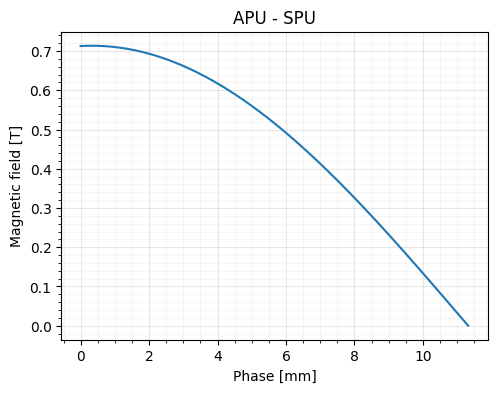

In [153]:
phases = np.linspace(0, apu22_spu_1991d.period/2 + apu22_spu_1991d.phase_coef["hp"]["z0"], 201)
apu22_spu_1991d.phase = phases

fields_eff_y = apu22_spu_1991d.get_apu_beff(apu22_spu_1991d, phase=phases)

plt.figure(figsize=(5.5, 4))
plt.title('APU - SPU')
plt.plot(phases, fields_eff_y)
plt.xlabel('Phase [mm]')
plt.ylabel('Magnetic field [T]')
plt.grid(which='major', alpha=0.3)
plt.grid(which='minor', alpha=0.1)
plt.minorticks_on()
plt.show()

In [154]:
data_apu_spu = np.zeros((fields_eff_y.size, 3))
data_apu_spu[:, 0] = phases
data_apu_spu[:, 1] = fields_eff_y * apu22_spu_1991d.period * 1e-3

In [155]:
header = """# HEADER
# ======
# label             si-id-apu22-1991d-horizontal
# harmonics         0
# main_harmonic     0 normal
# rescaling_factor  1.0
# units             mm   T.m T.m


# KParam    By[T]*Lamba[m]    Bx[T]*Lambda[m]
# =========================================="""


footer = """
# COMMENTS
# ========
#
# 1. Measurement data at the lnls-ima organization github in the repo:
#    https://github.com/lnls-ima/id-ema.git
#    This undulator used to be from EMA beamline, but it is now from SAPUCAIA.
#
# 2. K ~ 93.3729/(T.m) * (lambda * B)
#    This table contains lambda * B as a function of the ID configuration.
#    In terms of maximum deflection angle,
#        lambda * B == 2 * pi * Brho * x'_max
#        where x'_max is taken from fitting RK trajectory within
#        40 central periods (20 before and 20 after the ID center)
#
# 3. Polynomial of order 6 is fitted to data in order to filter out
#    data fluctuations. In this case the number of data points was not
#    increased in the fitting process.
#
# 4. Excdata is generated with script
#    'generate_tables.ipynb' at the lnls-ids organization github in the
#    excitation_data folder of the repo:
#    https://github.com/lnls-ids/insertion-devices.git'"""

np.savetxt(
    "./excitation_tables/si-id-apu22-1991d-horizontal.txt",
    data_apu_spu,
    fmt=["%05.2f", "%08.6e", "%08.6e"],
    delimiter="\t",
    header=header,
    footer=footer,
    comments="",
)

### APU22 (1991c) ARIRANHA 20SB

In [156]:
apu22_ari_1991c = APU22_1991C_ARI()

apu22_ari_1991c.polarization, apu22_ari_1991c.phase, apu22_ari_1991c.get_apu_beff(apu22_ari_1991c, phase=0), apu22_ari_1991c.min_gap

('hp', 0.0, 0.6841599630322569, 8.0)

In [157]:
apu22_ari_1991c.halbach_coef, apu22_ari_1991c.phase_coef, apu22_ari_1991c.br

({'hp': {'a': 1.732, 'b': -3.238, 'c': 0.0}},
 {'hp': {'ef': 0.95723745, 'z0': -0.18569034}},
 1.34)

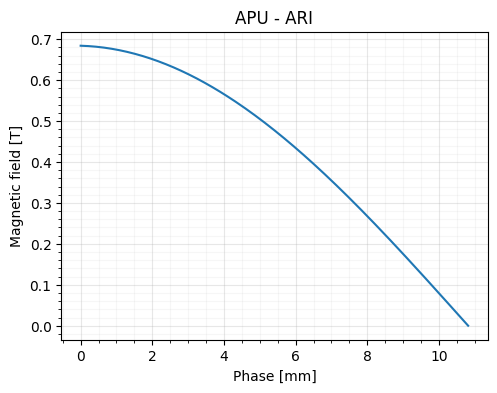

In [158]:
phases = np.linspace(0, apu22_ari_1991c.period/2 + apu22_ari_1991c.phase_coef["hp"]["z0"], 201)
apu22_ari_1991c.phase = phases

fields_eff_y = apu22_ari_1991c.get_apu_beff(apu22_ari_1991c, phase=phases)

plt.figure(figsize=(5.5, 4))
plt.title('APU - ARI')
plt.plot(phases, fields_eff_y)
plt.xlabel('Phase [mm]')
plt.ylabel('Magnetic field [T]')
plt.grid(which='major', alpha=0.3)
plt.grid(which='minor', alpha=0.1)
plt.minorticks_on()
plt.show()

In [159]:
data_apu_ari = np.zeros((fields_eff_y.size, 3))
data_apu_ari[:, 0] = phases
data_apu_ari[:, 1] = fields_eff_y * apu22_ari_1991c.period * 1e-3

In [160]:
header = """# HEADER
# ======
# label             si-id-apu22-1991c-horizontal
# harmonics         0
# main_harmonic     0 normal
# rescaling_factor  1.0
# units             mm   T.m T.m


# KParam    By[T]*Lamba[m]    Bx[T]*Lambda[m]
# =========================================="""


footer = """
# COMMENTS
# ========
#
# 1. Measurement data at the lnls-ima organization github in the repo:
#    https://github.com/lnls-ima/id-carnauba.git
#    This undulator used to be from CARNAUBA beamline, but it is now from
#    ARIRANHA.
#
# 2. K ~ 93.3729/(T.m) * (lambda * B)
#    This table contains lambda * B as a function of the ID configuration.
#    In terms of maximum deflection angle,
#        lambda * B == 2 * pi * Brho * x'_max
#        where x'_max is taken from fitting RK trajectory within
#        40 central periods (20 before and 20 after the ID center)
#
# 3. Polynomial of order 6 is fitted to data in order to filter out
#    data fluctuations. In this case the number of data points was not
#    increased in the fitting process.
#
# 4. Excdata is generated with script
#    'generate_tables.ipynb' at the lnls-ids organization github in the
#    excitation_data folder of the repo:
#    https://github.com/lnls-ids/insertion-devices.git'"""

np.savetxt(
    "./excitation_tables/si-id-apu22-1991c-horizontal.txt",
    data_apu_ari,
    fmt=["%05.2f", "%08.6e", "%08.6e"],
    delimiter="\t",
    header=header,
    footer=footer,
    comments="",
)

## DELTA

### DELTA52 SABIÁ 10SB

#### Horizontal polarization

In [161]:
delta52_sab_hp = DELTA52_SAB()
delta52_sab_hp.polarization = 'hp'
delta52_sab_hp.polarization, delta52_sab_hp.phase, delta52_sab_hp.get_apu_beff(delta52_sab_hp, phase=26.25), delta52_sab_hp.min_gap

('hp', 26.25, 1.2340934229679765, 13.6)

In [162]:
delta52_sab_hp.br, delta52_sab_hp.halbach_coef, delta52_sab_hp.phase_coef

(1.39,
 {'hp': {'a': 1.696, 'b': -2.349, 'c': -0.658},
  'vp': {'a': 1.696, 'b': -2.349, 'c': -0.658},
  'cp': {'a': 1.696, 'b': -2.349, 'c': -0.658}},
 {'hp': {'ef': 1.00566, 'z0': 25.89527},
  'vp': {'ef': 0.99032, 'z0': 26.08821},
  'cp': {'ef': 0.71497, 'z0': 25.89593}})

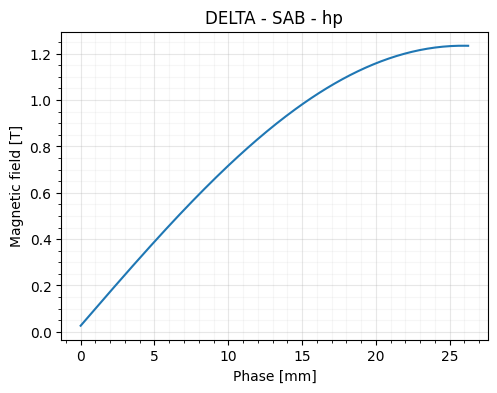

In [163]:
phases = np.linspace(0, delta52_sab_hp.period/2, 201)
delta52_sab_hp.phase = phases

fields_eff_y = delta52_sab_hp.get_apu_beff(delta52_sab_hp, phase=phases)

plt.figure(figsize=(5.5, 4))
plt.title('DELTA - SAB - hp')
plt.plot(phases, fields_eff_y)
plt.xlabel('Phase [mm]')
plt.ylabel('Magnetic field [T]')
plt.grid(which='major', alpha=0.3)
plt.grid(which='minor', alpha=0.1)
plt.minorticks_on()
plt.show()

In [164]:
data_delta_sab_hp = np.zeros((fields_eff_y.size, 3))
data_delta_sab_hp[:, 0] = phases
data_delta_sab_hp[:, 1] = fields_eff_y * delta52_sab_hp.period * 1e-3

In [165]:
header = """# HEADER
# ======
# label             si-id-delta52-horizontal
# harmonics         0
# main_harmonic     0 normal
# rescaling_factor  1.0
# units             mm   T.m T.m


# KParam    By[T]*Lamba[m]    Bx[T]*Lambda[m]
# =========================================="""


footer = """
# COMMENTS
# ========
#
# 1. Measurement data at the lnls-ima organization github in the repo:
#    lnls-ima/id-sabia.git
#
# 2. K ~ 93.3729/(T.m) * (lambda * B)
#    This table contains lambda * B as a function of the ID configuration.
#    In terms of maximum deflection angle,
#        lambda * B == 2 * pi * Brho * x'_max
#        where x'_max is taken from fitting RK trajectory within
#        40 central periods (20 before and 20 after the ID center)
#
# 3. Polynomial of order 6 is fitted to data in order to filter out
#    data fluctuations. In this case the number of data points was not
#    increased in the fitting process.
#
# 4. Excdata is generated with script
#    'generate_tables.ipynb' at the lnls-ids organization github in the
#    excitation_data folder of the repo:
#    https://github.com/lnls-ids/insertion-devices.git'"""

np.savetxt(
    "./excitation_tables/si-id-delta52-horizontal.txt",
    data_delta_sab_hp,
    fmt=["%05.2f", "%08.6e", "%08.6e"],
    delimiter="\t",
    header=header,
    footer=footer,
    comments="",
)

#### Vertical polarization

In [166]:
delta52_sab_vp = DELTA52_SAB()
delta52_sab_vp.polarization = 'vp'
delta52_sab_vp.polarization, delta52_sab_vp.phase, delta52_sab_vp.get_apu_beff(delta52_sab_vp, phase=26.25), delta52_sab_vp.min_gap

('vp', 26.25, 1.2154858520419942, 13.6)

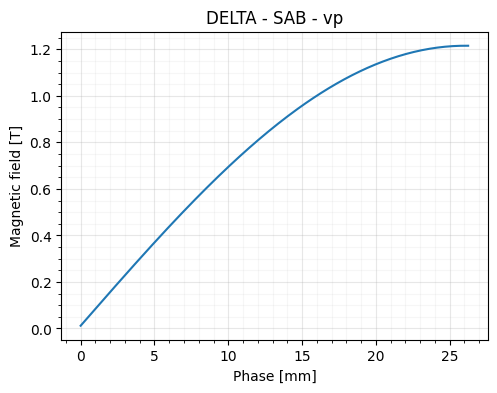

In [167]:
phases = np.linspace(0, delta52_sab_vp.period/2, 201)
delta52_sab_vp.phase = phases

fields_eff_y = delta52_sab_vp.get_apu_beff(delta52_sab_vp, phase=phases)

plt.figure(figsize=(5.5, 4))
plt.title('DELTA - SAB - vp')
plt.plot(phases, fields_eff_y)
plt.xlabel('Phase [mm]')
plt.ylabel('Magnetic field [T]')
plt.grid(which='major', alpha=0.3)
plt.grid(which='minor', alpha=0.1)
plt.minorticks_on()
plt.show()

In [168]:
data_delta_sab_vp = np.zeros((fields_eff_y.size, 3))
data_delta_sab_vp[:, 0] = phases
data_delta_sab_vp[:, 1] = fields_eff_y * delta52_sab_vp.period * 1e-3

In [169]:
header = """# HEADER
# ======
# label             si-id-delta52-vertical
# harmonics         0
# main_harmonic     0 normal
# rescaling_factor  1.0
# units             mm   T.m T.m


# KParam    By[T]*Lamba[m]    Bx[T]*Lambda[m]
# =========================================="""


footer = """
# COMMENTS
# ========
#
# 1. Measurement data at the lnls-ima organization github in the repo:
#    lnls-ima/id-sabia.git
#
# 2. K ~ 93.3729/(T.m) * (lambda * B)
#    This table contains lambda * B as a function of the ID configuration.
#    In terms of maximum deflection angle,
#        lambda * B == 2 * pi * Brho * x'_max
#        where x'_max is taken from fitting RK trajectory within
#        40 central periods (20 before and 20 after the ID center)
#
# 3. Polynomial of order 6 is fitted to data in order to filter out
#    data fluctuations. In this case the number of data points was not
#    increased in the fitting process.
#
# 4. Excdata is generated with script
#    'generate_tables.ipynb' at the lnls-ids organization github in the
#    excitation_data folder of the repo:
#    https://github.com/lnls-ids/insertion-devices.git'"""

np.savetxt(
    "./excitation_tables/si-id-delta52-vertical.txt",
    data_delta_sab_vp,
    fmt=["%05.2f", "%08.6e", "%08.6e"],
    delimiter="\t",
    header=header,
    footer=footer,
    comments="",
)

#### Circular polarization

In [170]:
delta52_sab_cp = DELTA52_SAB()
delta52_sab_cp.polarization = 'cp'
delta52_sab_cp.polarization, delta52_sab_cp.phase, delta52_sab_cp.get_apu_beff(delta52_sab_cp, phase=26.25), delta52_sab_cp.min_gap

('cp', 26.25, 0.8773745736609798, 13.6)

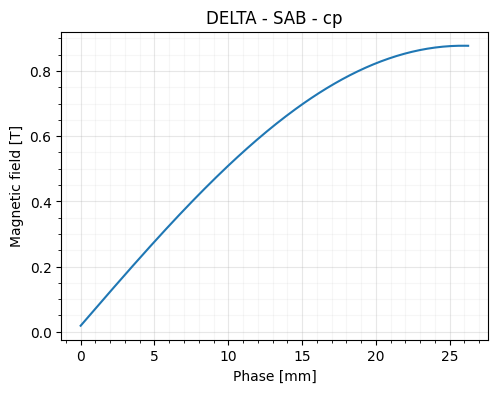

In [171]:
phases = np.linspace(0, delta52_sab_cp.period/2, 201)
delta52_sab_cp.phase = phases

fields_eff_y = delta52_sab_cp.get_apu_beff(delta52_sab_cp, phase=phases)

plt.figure(figsize=(5.5, 4))
plt.title('DELTA - SAB - cp')
plt.plot(phases, fields_eff_y)
plt.xlabel('Phase [mm]')
plt.ylabel('Magnetic field [T]')
plt.grid(which='major', alpha=0.3)
plt.grid(which='minor', alpha=0.1)
plt.minorticks_on()
plt.show()

In [172]:
header = """# HEADER
# ======
# label             si-id-delta52-circular
# harmonics         0
# main_harmonic     0 normal
# rescaling_factor  1.0
# units             mm   T.m T.m


# KParam    By[T]*Lamba[m]    Bx[T]*Lambda[m]
# =========================================="""


footer = """
# COMMENTS
# ========
#
# 1. Measurement data at the lnls-ima organization github in the repo:
#    lnls-ima/id-sabia.git
#
# 2. K ~ 93.3729/(T.m) * (lambda * B)
#    This table contains lambda * B as a function of the ID configuration.
#    In terms of maximum deflection angle,
#        lambda * B == 2 * pi * Brho * x'_max
#        where x'_max is taken from fitting RK trajectory within
#        40 central periods (20 before and 20 after the ID center)
#
# 3. Polynomial of order 6 is fitted to data in order to filter out
#    data fluctuations. In this case the number of data points was not
#    increased in the fitting process.
#
# 4. Excdata is generated with script
#    'generate_tables.ipynb' at the lnls-ids organization github in the
#    excitation_data folder of the repo:
#    https://github.com/lnls-ids/insertion-devices.git'"""

np.savetxt(
    "./excitation_tables/si-id-delta52-circular.txt",
    data_delta_sab_vp,
    fmt=["%05.2f", "%08.6e", "%08.6e"],
    delimiter="\t",
    header=header,
    footer=footer,
    comments="",
)

## IVUs (Horizontal polarization)

### IVU18 (IVU18-1) PAINEIRA 14SB

In [173]:
ivu18_pnr_1 = IVU18_1_PNR()

ivu18_pnr_1.polarization, ivu18_pnr_1.get_mgu_beff(ivu18_pnr_1, gap=ivu18_pnr_1.min_gap), ivu18_pnr_1.min_gap

('hp', 1.249582572029963, 4.3)

In [174]:
ivu18_pnr_1.br, ivu18_pnr_1.halbach_coef

(1.27, {'hp': {'a': 2.29044642, 'b': -3.71638253, 'c': 0.34898287}})

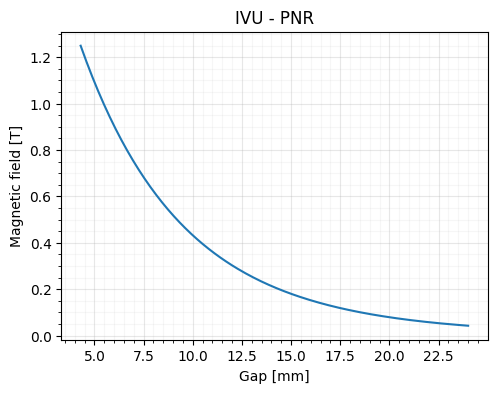

In [175]:
gaps = np.linspace(ivu18_pnr_1.min_gap, 24, 201)
fields_eff_y = np.array([ivu18_pnr_1.get_mgu_beff(ivu18_pnr_1, gap=gap) for gap in gaps])

plt.figure(figsize=(5.5, 4))
plt.title('IVU - PNR')
plt.plot(gaps, fields_eff_y)
plt.xlabel('Gap [mm]')
plt.ylabel('Magnetic field [T]')
plt.grid(which='major', alpha=0.3)
plt.grid(which='minor', alpha=0.1)
plt.minorticks_on()
plt.show()

In [176]:
data_ivu_pnr = np.zeros((fields_eff_y.size, 3))
data_ivu_pnr[:, 0] = gaps
data_ivu_pnr[:, 1] = fields_eff_y * ivu18_pnr_1.period * 1e-3

In [177]:
header = """# HEADER
# ======
# label             si-id-ivu18-1-horizontal
# harmonics         0
# main_harmonic     0 normal
# rescaling_factor  1.0
# units             mm   T.m T.m


# KParam    By[T]*Lamba[m]    Bx[T]*Lambda[m]
# =========================================="""


footer = """
# COMMENTS
# ========
#
# 1. Measurement data at the undulators sharepoint in the folder:
#    https://cnpemcamp.sharepoint.com/:f:/s/lnls/projects/Undulators/IgBpAvt3uf_1S7GbpbJE43ZEAQcuq71O0H_gg_74WeOCOC8?e=kFCQ4v
#
# 2. K ~ 93.3729/(T.m) * (lambda * B)
#    This table contains lambda * B as a function of the ID configuration.
#    In terms of maximum deflection angle,
#        lambda * B == 2 * pi * Brho * x'_max
#        where x'_max is taken from fitting RK trajectory within
#        40 central periods (20 before and 20 after the ID center)
#
# 3. Polynomial of order 6 is fitted to data in order to filter out
#    data fluctuations. In this case the number of data points was not
#    increased in the fitting process.
#
# 4. Excdata is generated with script
#    'generate_tables.ipynb' at the lnls-ids organization github in the
#    excitation_data folder of the repo:
#    https://github.com/lnls-ids/insertion-devices.git'"""

np.savetxt(
    "./excitation_tables/si-id-ivu18-1-horizontal.txt",
    data_ivu_pnr,
    fmt=["%05.2f", "%08.6e", "%08.6e"],
    delimiter="\t",
    header=header,
    footer=footer,
    comments="",
)

### IVU18 (IVU18-2) EMA 08SB

In [178]:
ivu18_ema_2 = IVU18_2_EMA()

ivu18_ema_2.polarization, ivu18_ema_2.get_mgu_beff(ivu18_ema_2, gap=ivu18_ema_2.min_gap), ivu18_ema_2.min_gap

('hp', 1.2381827249128505, 4.3)

In [179]:
ivu18_ema_2.br, ivu18_ema_2.halbach_coef

(1.27, {'hp': {'a': 2.26223181, 'b': -3.69776472, 'c': 0.32867209}})

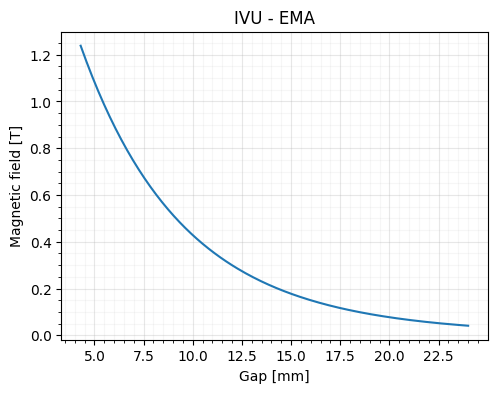

In [180]:
gaps = np.linspace(ivu18_ema_2.min_gap, 24, 201)
fields_eff_y = np.array([ivu18_ema_2.get_mgu_beff(ivu18_ema_2, gap=gap) for gap in gaps])

plt.figure(figsize=(5.5, 4))
plt.title('IVU - EMA')
plt.plot(gaps, fields_eff_y)
plt.xlabel('Gap [mm]')
plt.ylabel('Magnetic field [T]')
plt.grid(which='major', alpha=0.3)
plt.grid(which='minor', alpha=0.1)
plt.minorticks_on()
plt.show()

In [181]:
data_ivu_ema = np.zeros((fields_eff_y.size, 3))
data_ivu_ema[:, 0] = gaps
data_ivu_ema[:, 1] = fields_eff_y * ivu18_ema_2.period * 1e-3

In [182]:
header = """# HEADER
# ======
# label             si-id-ivu18-2-horizontal
# harmonics         0
# main_harmonic     0 normal
# rescaling_factor  1.0
# units             mm   T.m T.m


# KParam    By[T]*Lamba[m]    Bx[T]*Lambda[m]
# =========================================="""


footer = """
# COMMENTS
# ========
#
# 1. Measurement data at the undulators sharepoint in the folder:
#    https://cnpemcamp.sharepoint.com/:f:/s/lnls/projects/Undulators/IgBFLzUIaGVJSp9u1Uv6zYK5AXt0Q4XQJ8vejMQ2tMyjYuU?e=Mds57E
#
# 2. K ~ 93.3729/(T.m) * (lambda * B)
#    This table contains lambda * B as a function of the ID configuration.
#    In terms of maximum deflection angle,
#        lambda * B == 2 * pi * Brho * x'_max
#        where x'_max is taken from fitting RK trajectory within
#        40 central periods (20 before and 20 after the ID center)
#
# 3. Polynomial of order 6 is fitted to data in order to filter out
#    data fluctuations. In this case the number of data points was not
#    increased in the fitting process.
#
# 4. Excdata is generated with script
#    'generate_tables.ipynb' at the lnls-ids organization github in the
#    excitation_data folder of the repo:
#    https://github.com/lnls-ids/insertion-devices.git'"""

np.savetxt(
    "./excitation_tables/si-id-ivu18-2-horizontal.txt",
    data_ivu_ema,
    fmt=["%05.2f", "%08.6e", "%08.6e"],
    delimiter="\t",
    header=header,
    footer=footer,
    comments="",
)

## VPUs (Vertical polarization)

### VPU29 (VPU29b) CARNAÚBA 06SB

In [183]:
vpu29_cnb_b = VPU29_B_CNB()

vpu29_cnb_b.polarization, vpu29_cnb_b.get_mgu_beff(vpu29_cnb_b, gap=vpu29_cnb_b.min_gap), vpu29_cnb_b.min_gap

('vp', 0.8552260950349654, 9.7)

In [184]:
vpu29_cnb_b.br, vpu29_cnb_b.halbach_coef

(1.304, {'vp': {'a': 2.03304573, 'b': -3.4431994, 'c': 0.18171406}})

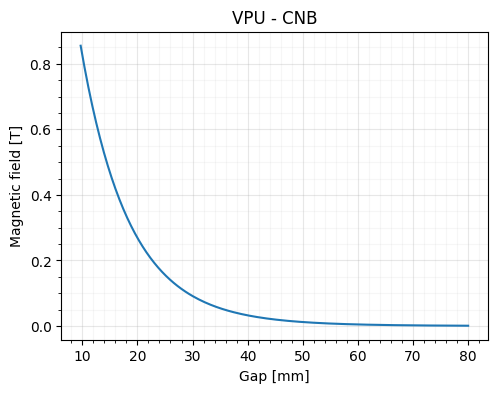

In [185]:
gaps = np.linspace(vpu29_cnb_b.min_gap, 80, 201)
fields_eff_x = np.array([vpu29_cnb_b.get_mgu_beff(vpu29_cnb_b, gap=gap) for gap in gaps])

plt.figure(figsize=(5.5, 4))
plt.title('VPU - CNB')
plt.plot(gaps, fields_eff_x)
plt.xlabel('Gap [mm]')
plt.ylabel('Magnetic field [T]')
plt.grid(which='major', alpha=0.3)
plt.grid(which='minor', alpha=0.1)
plt.minorticks_on()
plt.show()

In [186]:
data_vpu_cnb = np.zeros((fields_eff_x.size, 3))
data_vpu_cnb[:, 0] = gaps
data_vpu_cnb[:, 2] = fields_eff_x * vpu29_cnb_b.period * 1e-3

In [187]:
header = """# HEADER
# ======
# label             si-id-vpu29-b-vertical
# harmonics         0
# main_harmonic     0 normal
# rescaling_factor  1.0
# units             mm   T.m T.m


# KParam    By[T]*Lamba[m]    Bx[T]*Lambda[m]
# =========================================="""


footer = """
# COMMENTS
# ========
#
# 1. Measurement data at the lnls-ima organization github in the repo:
#    https://github.com/lnls-ima/id-VPU29-2386b
#
# 2. K ~ 93.3729/(T.m) * (lambda * B)
#    This table contains lambda * B as a function of the ID configuration.
#    In terms of maximum deflection angle,
#        lambda * B == 2 * pi * Brho * x'_max
#        where x'_max is taken from fitting RK trajectory within
#        40 central periods (20 before and 20 after the ID center)
#
# 3. Polynomial of order 6 is fitted to data in order to filter out
#    data fluctuations. In this case the number of data points was not
#    increased in the fitting process.
#
# 4. Excdata is generated with script
#    'generate_tables.ipynb' at the lnls-ids organization github in the
#    excitation_data folder of the repo:
#    https://github.com/lnls-ids/insertion-devices.git'"""

np.savetxt(
    "./excitation_tables/si-id-vpu29-b-vertical.txt",
    data_vpu_cnb,
    fmt=["%05.2f", "%08.6e", "%08.6e"],
    delimiter="\t",
    header=header,
    footer=footer,
    comments="",
)

### VPU29 (VPU29a) CATERETÊ 07SP

In [188]:
vpu29_cat_a = VPU29_A_CAT()

vpu29_cat_a.polarization, vpu29_cat_a.get_mgu_beff(vpu29_cat_a, gap=vpu29_cat_a.min_gap), vpu29_cat_a.min_gap

('vp', 0.8268560934727447, 9.7)

In [189]:
vpu29_cnb_b.br, vpu29_cnb_b.halbach_coef

(1.304, {'vp': {'a': 2.03304573, 'b': -3.4431994, 'c': 0.18171406}})

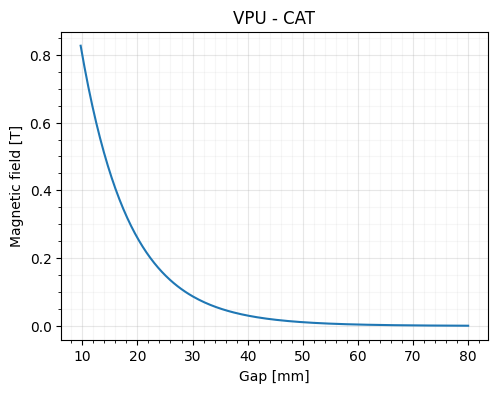

In [190]:
gaps = np.linspace(vpu29_cat_a.min_gap, 80, 201)
fields_eff_x = np.array([vpu29_cat_a.get_mgu_beff(vpu29_cat_a, gap=gap) for gap in gaps])

plt.figure(figsize=(5.5, 4))
plt.title('VPU - CAT')
plt.plot(gaps, fields_eff_x)
plt.xlabel('Gap [mm]')
plt.ylabel('Magnetic field [T]')
plt.grid(which='major', alpha=0.3)
plt.grid(which='minor', alpha=0.1)
plt.minorticks_on()
plt.show()

In [191]:
data_vpu_cat = np.zeros((fields_eff_x.size, 3))
data_vpu_cat[:, 0] = gaps
data_vpu_cat[:, 2] = fields_eff_x * vpu29_cat_a.period * 1e-3

In [192]:
header = """# HEADER
# ======
# label             si-id-vpu29-a-vertical
# harmonics         0
# main_harmonic     0 normal
# rescaling_factor  1.0
# units             mm   T.m T.m


# KParam    By[T]*Lamba[m]    Bx[T]*Lambda[m]
# =========================================="""


footer = """
# COMMENTS
# ========
#
# 1. Measurement data at the sharepoint Undulators in the folder:
#    https://cnpemcamp.sharepoint.com/:f:/s/lnls/projects/Undulators/IgARGR7V1PbUT7t4Gw8GvpxMAY8hM8mLX1V2sWo-HbsUD7g?e=J239kC
#
# 2. K ~ 93.3729/(T.m) * (lambda * B)
#    This table contains lambda * B as a function of the ID configuration.
#    In terms of maximum deflection angle,
#        lambda * B == 2 * pi * Brho * x'_max
#        where x'_max is taken from fitting RK trajectory within
#        40 central periods (20 before and 20 after the ID center)
#
# 3. Polynomial of order 6 is fitted to data in order to filter out
#    data fluctuations. In this case the number of data points was not
#    increased in the fitting process.
#
# 4. Excdata is generated with script
#    'generate_tables.ipynb' at the lnls-ids organization github in the
#    excitation_data folder of the repo:
#    https://github.com/lnls-ids/insertion-devices.git'"""

np.savetxt(
    "./excitation_tables/si-id-vpu29-a-vertical.txt",
    data_vpu_cat,
    fmt=["%05.2f", "%08.6e", "%08.6e"],
    delimiter="\t",
    header=header,
    footer=footer,
    comments="",
)

## UE

### UE44 (UE44) IPÊ 11SP

#### Horizontal polarization

In [193]:
ue44_hp_ipe = UE44_IPE()

ue44_hp_ipe.polarization, ue44_hp_ipe.phase, ue44_hp_ipe.get_apu_beff(ue44_hp_ipe, phase=0), ue44_hp_ipe.min_gap

('hp', 0.0, 0.8588879741246113, 11.4)

In [194]:
ue44_hp_ipe.br, ue44_hp_ipe.halbach_coef, ue44_hp_ipe.phase_coef

(1.14,
 {'hp': {'a': 1.4934, 'b': -2.5933, 'c': -0.4855},
  'vp': {'a': 2.0362, 'b': -5.4204, 'c': 1.1888},
  'cp': {'a': 1.6558, 'b': -5.1381, 'c': 1.4244},
  'lp54x': {'a': 1.3581, 'b': -4.5943, 'c': 0.8108}},
 {'hp': {'ef': 1.0205, 'z0': -0.028},
  'vp': {'ef': 0.9933, 'z0': -0.062},
  'cp': {'ef': 0.9116, 'z0': 0.0245},
  'lp54x': {'ef': 1.0041, 'z0': -0.047}})

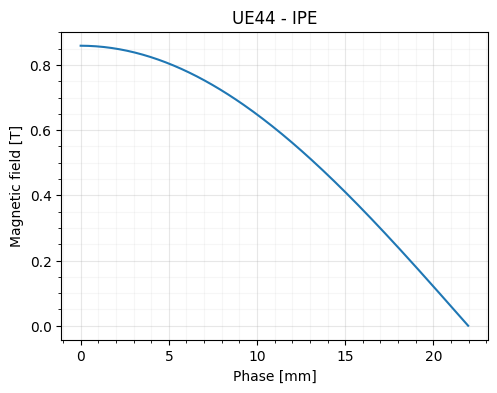

In [195]:
phases = np.linspace(0, ue44_hp_ipe.period/2 + ue44_hp_ipe.phase_coef["hp"]["z0"], 201)
ue44_hp_ipe.phase = phases

fields_eff_y = ue44_hp_ipe.get_apu_beff(ue44_hp_ipe, phase=phases)

plt.figure(figsize=(5.5, 4))
plt.title('UE44 - IPE')
plt.plot(phases, fields_eff_y)
plt.xlabel('Phase [mm]')
plt.ylabel('Magnetic field [T]')
plt.grid(which='major', alpha=0.3)
plt.grid(which='minor', alpha=0.1)
plt.minorticks_on()
plt.show()

In [196]:
data_ue_hp_ipe = np.zeros((fields_eff_y.size, 3))
data_ue_hp_ipe[:, 0] = phases
data_ue_hp_ipe[:, 1] = fields_eff_y * ue44_hp_ipe.period * 1e-3

In [197]:
header = """# HEADER
# ======
# label             si-id-ue44-horizontal
# harmonics         0
# main_harmonic     0 normal
# rescaling_factor  1.0
# units             mm   T.m T.m


# KParam    By[T]*Lamba[m]    Bx[T]*Lambda[m]
# =========================================="""


footer = """
# COMMENTS
# ========
#
# 1. Measurement data at the sharepoint undulators:
#    https://cnpemcamp.sharepoint.com/:f:/s/lnls/projects/Undulators/IgA3bd53KAlKSJ_5A4QNXcnWASNjCeDJ-RjK-mj16EaL4tw?e=s6iVw6
#
# 2. K ~ 93.3729/(T.m) * (lambda * B)
#    This table contains lambda * B as a function of the ID configuration.
#    In terms of maximum deflection angle,
#        lambda * B == 2 * pi * Brho * x'_max
#        where x'_max is taken from fitting RK trajectory within
#        40 central periods (20 before and 20 after the ID center)
#
# 3. Polynomial of order 6 is fitted to data in order to filter out
#    data fluctuations. In this case the number of data points was not
#    increased in the fitting process.
#
# 4. Excdata is generated with script
#    'generate_tables.ipynb' at the lnls-ids organization github in the
#    excitation_data folder of the repo:
#    https://github.com/lnls-ids/insertion-devices.git'"""

np.savetxt(
    "./excitation_tables/si-id-ue44-horizontal.txt",
    data_ue_hp_ipe,
    fmt=["%05.2f", "%08.6e", "%08.6e"],
    delimiter="\t",
    header=header,
    footer=footer,
    comments="",
)

#### Vertical polarization

In [198]:
ue44_vp_ipe = UE44_IPE()
ue44_vp_ipe.polarization = 'vp'

ue44_vp_ipe.polarization, ue44_vp_ipe.phase, ue44_vp_ipe.get_apu_beff(ue44_vp_ipe, phase=0), ue44_vp_ipe.min_gap

('vp', 0.0, 0.6131208389768711, 11.4)

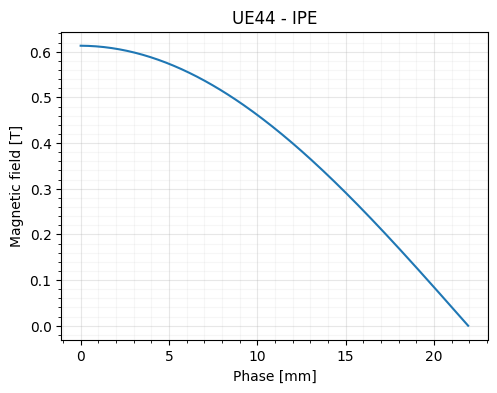

In [199]:
phases = np.linspace(0, ue44_vp_ipe.period/2 + ue44_vp_ipe.phase_coef["vp"]["z0"], 201)
ue44_vp_ipe.phase = phases

fields_eff_x = ue44_vp_ipe.get_apu_beff(ue44_vp_ipe, phase=phases)

plt.figure(figsize=(5.5, 4))
plt.title('UE44 - IPE')
plt.plot(phases, fields_eff_x)
plt.xlabel('Phase [mm]')
plt.ylabel('Magnetic field [T]')
plt.grid(which='major', alpha=0.3)
plt.grid(which='minor', alpha=0.1)
plt.minorticks_on()
plt.show()

In [200]:
data_ue_vp_ipe = np.zeros((fields_eff_x.size, 3))
data_ue_vp_ipe[:, 0] = phases
data_ue_vp_ipe[:, 2] = fields_eff_x * ue44_vp_ipe.period * 1e-3

In [201]:
header = """# HEADER
# ======
# label             si-id-ue44-vertical
# harmonics         0
# main_harmonic     0 normal
# rescaling_factor  1.0
# units             mm   T.m T.m


# KParam    By[T]*Lamba[m]    Bx[T]*Lambda[m]
# =========================================="""


footer = """
# COMMENTS
# ========
#
# 1. Measurement data at the sharepoint undulators:
#    https://cnpemcamp.sharepoint.com/:f:/s/lnls/projects/Undulators/IgA3bd53KAlKSJ_5A4QNXcnWASNjCeDJ-RjK-mj16EaL4tw?e=f1dFxD
#
# 2. K ~ 93.3729/(T.m) * (lambda * B)
#    This table contains lambda * B as a function of the ID configuration.
#    In terms of maximum deflection angle,
#        lambda * B == 2 * pi * Brho * x'_max
#        where x'_max is taken from fitting RK trajectory within
#        40 central periods (20 before and 20 after the ID center)
#
# 3. Polynomial of order 6 is fitted to data in order to filter out
#    data fluctuations. In this case the number of data points was not
#    increased in the fitting process.
#
# 4. Excdata is generated with script
#    'generate_tables.ipynb' at the lnls-ids organization github in the
#    excitation_data folder of the repo:
#    https://github.com/lnls-ids/insertion-devices.git'"""

np.savetxt(
    "./excitation_tables/si-id-ue44-vertical.txt",
    data_ue_vp_ipe,
    fmt=["%05.2f", "%08.6e", "%08.6e"],
    delimiter="\t",
    header=header,
    footer=footer,
    comments="",
)

#### Circular polarization

In [202]:
ue44_cp_ipe = UE44_IPE()
ue44_cp_ipe.polarization = 'cp'

ue44_cp_ipe.polarization, ue44_cp_ipe.phase, ue44_cp_ipe.get_apu_beff(ue44_cp_ipe, phase=0), ue44_cp_ipe.min_gap

('cp', 0.0, 0.5001432562795677, 11.4)

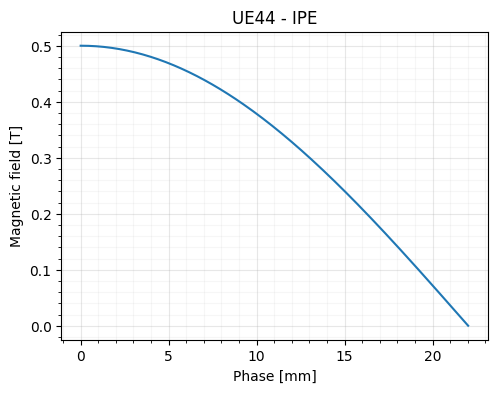

In [203]:
phases = np.linspace(0, ue44_cp_ipe.period/2 + ue44_cp_ipe.phase_coef["cp"]["z0"], 201)
ue44_cp_ipe.phase = phases

fields_eff_x = ue44_cp_ipe.get_apu_beff(ue44_cp_ipe, phase=phases)

plt.figure(figsize=(5.5, 4))
plt.title('UE44 - IPE')
plt.plot(phases, fields_eff_x)
plt.xlabel('Phase [mm]')
plt.ylabel('Magnetic field [T]')
plt.grid(which='major', alpha=0.3)
plt.grid(which='minor', alpha=0.1)
plt.minorticks_on()
plt.show()

In [204]:
data_ue_cp_ipe = np.zeros((fields_eff_x.size, 3))
data_ue_cp_ipe[:, 0] = phases
data_ue_cp_ipe[:, 2] = fields_eff_x * ue44_cp_ipe.period * 1e-3

In [205]:
header = """# HEADER
# ======
# label             si-id-ue44-circular
# harmonics         0
# main_harmonic     0 normal
# rescaling_factor  1.0
# units             mm   T.m T.m


# KParam    By[T]*Lamba[m]    Bx[T]*Lambda[m]
# =========================================="""


footer = """
# COMMENTS
# ========
#
# 1. Measurement data at the sharepoint undulators:
#    https://cnpemcamp.sharepoint.com/:f:/s/lnls/projects/Undulators/IgA3bd53KAlKSJ_5A4QNXcnWASNjCeDJ-RjK-mj16EaL4tw?e=f1dFxD
#
# 2. K ~ 93.3729/(T.m) * (lambda * B)
#    This table contains lambda * B as a function of the ID configuration.
#    In terms of maximum deflection angle,
#        lambda * B == 2 * pi * Brho * x'_max
#        where x'_max is taken from fitting RK trajectory within
#        40 central periods (20 before and 20 after the ID center)
#
# 3. Polynomial of order 6 is fitted to data in order to filter out
#    data fluctuations. In this case the number of data points was not
#    increased in the fitting process.
#
# 4. Excdata is generated with script
#    'generate_tables.ipynb' at the lnls-ids organization github in the
#    excitation_data folder of the repo:
#    https://github.com/lnls-ids/insertion-devices.git"""

np.savetxt(
    "./excitation_tables/si-id-ue44-circular.txt",
    data_ue_cp_ipe,
    fmt=["%05.2f", "%08.6e", "%08.6e"],
    delimiter="\t",
    header=header,
    footer=footer,
    comments="",
)

#### Transition region (horizontal <-> vertical polarization)